In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn import preprocessing
from clipn import CLIPn
import argparse
import matplotlib.pyplot as plt
sys.path.insert(0, "./utils")
from readProfiles import read_paired_treatment_level_profiles

/home/intern/jiwoo/miniconda3/envs/clip/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Preexe

In [7]:
def _scale(df, cols):
    ss = preprocessing.StandardScaler()
    mm = preprocessing.MinMaxScaler((0, 1))
    X = df[cols].values.astype("float64")
    X = mm.fit_transform(ss.fit_transform(X))
    out = df.copy()
    out.loc[:, cols] = X
    return out

In [8]:
def make_df_all_and_features(
    procProf_dir: str,
    dataset: str,                      # "LINCS" or "CDRP-bio"
    profileType: str,
    filter_perts: str,
    repCorrFilePath: str,
    nSamplesMOA: int = 4,
):
    """
    Returns:
      df_all: merged_scaled에서 MoA selection까지 끝난 DF (원본 row 단위)
      X_ef:  (N, D_cp + D_ge) early fusion features
      X_cp:  (N, D_cp)
      moa_str: (N,) MoA string labels (lowercased)
      groups: (N,) compound ids (13 char)
      cp_features, l1k_features_full: feature name lists
      pertColName, moa_col: used column names
    """
    # 너 코드와 동일한 이름/설정
    pertColName = "PERT"
    moa_col = "Metadata_MoA"

    filter_repCorr_params = [filter_perts, repCorrFilePath]

    merg, cp_features, l1k_features_full = read_paired_treatment_level_profiles(
        procProf_dir, dataset, profileType, filter_repCorr_params, 1
    )

    # -------- harmonize (너 코드 그대로) --------
    merg = merg.copy()
    if dataset == "LINCS":
        merg[moa_col] = merg["Metadata_moa"]
        merg.loc[merg["Metadata_moa"].isnull(), moa_col] = (
            merg.loc[merg["Metadata_moa"].isnull(), "moa"].astype(str).str.lower()
        )
        merg["Compounds"] = merg[pertColName].astype(str).str[0:13]
    else:
        merg[moa_col] = merg["Metadata_moa"].astype(str).str.lower()
        merg["Compounds"] = merg[pertColName].astype(str).str[0:13]

    # -------- CP/GE scale + concat (너 코드 그대로) --------
    cp = merg[[pertColName, "Compounds", moa_col] + list(cp_features)].copy()
    ge = merg[[pertColName, "Compounds", moa_col] + list(l1k_features_full)].copy()

    cp_s = _scale(cp, list(cp_features))
    ge_s = _scale(ge, list(l1k_features_full))

    merged_scaled = pd.concat([cp_s, ge_s], axis=1)
    merged_scaled = merged_scaled.loc[:, ~merged_scaled.columns.duplicated()].copy()
    merged_scaled["Compounds"] = merged_scaled[pertColName].astype(str).str[0:13]

    # -------- select MoAs by compound count (너 코드 그대로) --------
    tmp = (
        merged_scaled.groupby(["Compounds"]).sample(1, random_state=0)
        .groupby([moa_col]).size()
        .reset_index(name="size")
        .sort_values("size", ascending=False)
    )
    selected = tmp[tmp["size"] > nSamplesMOA][moa_col].tolist()
    multi = [m for m in selected if isinstance(m, str) and "|" in m]
    selected = [m for m in selected if m not in multi]

    df_all = merged_scaled[merged_scaled[moa_col].isin(selected)].reset_index(drop=True).copy()

    # -------- build matrices --------
    X_cp = df_all[list(cp_features)].to_numpy(dtype=np.float32)
    X_ge = df_all[list(l1k_features_full)].to_numpy(dtype=np.float32)
    X_ef = np.concatenate([X_cp, X_ge], axis=1).astype(np.float32)

    moa_str = df_all[moa_col].astype(str).str.strip().str.lower().to_numpy()
    groups  = df_all["Compounds"].astype(str).to_numpy()

    return dict(
        df_all=df_all,
        X_ef=X_ef,
        X_cp=X_cp,
        moa_str=moa_str,
        groups=groups,
        cp_features=list(cp_features),
        ge_features=list(l1k_features_full),
        pertColName=pertColName,
        moa_col=moa_col,
    )

In [12]:
def build_clipn_Xy_from_two_datasets(
    cdrp_obj: dict,
    lincs_obj: dict,
    keep_common_moas: bool = True,
    one_sample_per_compound: bool = True,
    random_state: int = 0,
    use: str = "cp",   # "cp" or "ef"
):
    """
    Returns:
      X: {0: X_cdrp, 1: X_lincs}
      y: {0: y_cdrp, 1: y_lincs}  # shared label ids
      label_to_id: dict[str,int]
      info: dict
    """
    assert use in ("cp", "ef"), "use must be 'cp' or 'ef'"

    def _pick_X(obj):
        return obj["X_cp"] if use == "cp" else obj["X_ef"]

    def _one_per_compound(df_all: pd.DataFrame, X: np.ndarray, moa_col: str):
        # 1 row per compound (reproducible)
        picked = df_all.groupby(["Compounds"], sort=False).sample(1, random_state=random_state)

        idx = picked.index.to_numpy()
        moa = picked[moa_col].astype(str).str.strip().str.lower().to_numpy()

        Xp = X[idx]
        return Xp, moa

    # unpack
    df_c, moa_col_c = cdrp_obj["df_all"], cdrp_obj["moa_col"]
    df_l, moa_col_l = lincs_obj["df_all"], lincs_obj["moa_col"]

    Xc = _pick_X(cdrp_obj)
    Xl = _pick_X(lincs_obj)

    # optional: 1 per compound
    moa_c = cdrp_obj["moa_str"]
    moa_l = lincs_obj["moa_str"]
    if one_sample_per_compound:
        Xc, moa_c = _one_per_compound(df_c, Xc, moa_col_c)
        Xl, moa_l = _one_per_compound(df_l, Xl, moa_col_l)

    # label space
    moas_c = set(moa_c.tolist())
    moas_l = set(moa_l.tolist())

    if keep_common_moas:
        label_space = sorted(moas_c.intersection(moas_l))
        mask_c = np.isin(moa_c, label_space)
        mask_l = np.isin(moa_l, label_space)
        Xc, moa_c = Xc[mask_c], moa_c[mask_c]
        Xl, moa_l = Xl[mask_l], moa_l[mask_l]
    else:
        label_space = sorted(moas_c.union(moas_l))

    label_to_id = {lab: i for i, lab in enumerate(label_space)}
    y_c = np.array([label_to_id[m] for m in moa_c], dtype=np.int64)
    y_l = np.array([label_to_id[m] for m in moa_l], dtype=np.int64)

    # safety: NaN/Inf
    Xc = np.nan_to_num(Xc, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    Xl = np.nan_to_num(Xl, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    X = {0: Xc, 1: Xl}
    y = {0: y_c, 1: y_l}

    info = {
        "use": use,
        "cdrp_shape": Xc.shape,
        "lincs_shape": Xl.shape,
        "n_labels": len(label_space),
        "cdrp_n": len(y_c),
        "lincs_n": len(y_l),
        "keep_common_moas": keep_common_moas,
        "one_sample_per_compound": one_sample_per_compound,
    }
    return X, y, label_to_id, info

In [11]:
def umap_scatter(Z_dict, y_dict, n_neighbors=15, min_dist=0.1, random_state=0, s=4):
    # Z_dict: {k: (n, d)} , y_dict: {k: (n,)}
    keys = sorted(Z_dict.keys(), key=lambda x: str(x))

    Z_all = np.vstack([Z_dict[k] for k in keys])
    y_all = np.concatenate([np.asarray(y_dict[k]) for k in keys])
    d_all = np.concatenate([np.full(len(y_dict[k]), str(k)) for k in keys])

    emb = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=random_state
    ).fit_transform(Z_all)

    # colored by label
    plt.figure(figsize=(6,5))
    plt.scatter(emb[:,0], emb[:,1], c=y_all, s=s, cmap="tab20")
    plt.title("CLIPn latent UMAP (colored by label)")
    plt.axis("equal")
    plt.show()

    # colored by dataset id
    # (문자열을 색으로 쓰려면 factorize 필요)
    d_code, _ = pd.factorize(d_all)
    plt.figure(figsize=(6,5))
    plt.scatter(emb[:,0], emb[:,1], c=d_code, s=s, cmap="tab10")
    plt.title("CLIPn latent UMAP (colored by dataset)")
    plt.axis("equal")
    plt.show()

# Run

In [10]:
def parse_args():
    ap = argparse.ArgumentParser()

    ap.add_argument("--procProf_dir", default="./",
                    help="processed profiles root dir (passed to read_paired_treatment_level_profiles)")
    ap.add_argument("--profileType", default="normalized_variable_selected",
                    help="profile type name used by loader")
    ap.add_argument("--filter_perts", default="highRepUnion",
                    help="pert filtering mode, e.g. highRepUnion")
    ap.add_argument("--repCorrFilePath", default="./results/RepCor/RepCorrDF.xlsx",
                    help="repCorr excel path")
    ap.add_argument("--nSamplesMOA", type=int, default=4,
                    help="min #compounds per MoA to keep (your script uses > nSamplesMOA)")

    # optional knobs for XY building
    ap.add_argument("--keep_common_moas", action="store_true",
                    help="keep only MoAs present in both datasets")
    ap.add_argument("--one_sample_per_compound", action="store_true",
                    help="sample 1 row per compound (recommended for MoA)")
    ap.add_argument("--random_state", type=int, default=0)

    return ap.parse_args()

args = parse_args()

In [14]:
# CDRP-bio
cdrp = make_df_all_and_features(
    procProf_dir=args.procProf_dir,
    dataset="CDRP-bio",
    profileType=args.profileType,
    filter_perts=args.filter_perts,
    repCorrFilePath=args.repCorrFilePath,
    nSamplesMOA=args.nSamplesMOA,
)

# LINCS
lincs = make_df_all_and_features(
    procProf_dir=args.procProf_dir,
    dataset="LINCS",
    profileType=args.profileType,
    filter_perts=args.filter_perts,
    repCorrFilePath=args.repCorrFilePath,
    nSamplesMOA=args.nSamplesMOA,
)

./utils/readProfiles.py:198: DtypeWarning: Columns (981,982,983) have mixed types.Specify dtype option on import or set low_memory=False.
  dataset_rootDir, dataset, profileType, per_plate_normalized_flag


CDRP-bio: Replicate Level Shapes (nSamples x nFeatures): cp:  21122 , 601 ,  l1k:  6929 , 977
l1k n of rep:  2.0
cp n of rep:  8.0
Treatment Level Shapes (nSamples x nFeatures+metadata): (2242, 604) (1917, 978) Merged Profiles Shape: (1919, 1581)


./utils/readProfiles.py:198: DtypeWarning: Columns (18,19,1249,1250) have mixed types.Specify dtype option on import or set low_memory=False.
  dataset_rootDir, dataset, profileType, per_plate_normalized_flag


LINCS: Replicate Level Shapes (nSamples x nFeatures): cp:  52223 , 119 ,  l1k:  27837 , 978
l1k n of rep:  3.0
cp n of rep:  5.0
Treatment Level Shapes (nSamples x nFeatures+metadata): (9395, 122) (8370, 980) Merged Profiles Shape: (6985, 1101)


In [24]:
# CLIPn 입력 만들기
X_cp, y_cp, label_to_id_cp, info_cp = build_clipn_Xy_from_two_datasets(
    cdrp, lincs,
    keep_common_moas=True,
    one_sample_per_compound=False,
    random_state=0,
    use="cp",
)

print(info_cp)

{'use': 'cp', 'cdrp_shape': (523, 601), 'lincs_shape': (2105, 119), 'n_labels': 33, 'cdrp_n': 523, 'lincs_n': 2105, 'keep_common_moas': True, 'one_sample_per_compound': False}


In [25]:
X_ef, y_ef, label_to_id_ef, info_ef = build_clipn_Xy_from_two_datasets(
    cdrp, lincs,
    keep_common_moas=True,
    one_sample_per_compound=False,
    random_state=0,
    use="ef",
)

In [32]:
# run CLIPn
data = "ef" # "ef"

if data == "cp":
    X, y = X_cp, y_cp
elif data == "ef":
    X, y = X_ef, y_ef

clipn = CLIPn(X, y, latent_dim=30)
loss = clipn.fit(X, y, lr=3e-4, epochs=800)
z = clipn.predict(X)

Running CLIPn ...


100%|██████████| 800/800 [01:13<00:00, 10.82it/s]


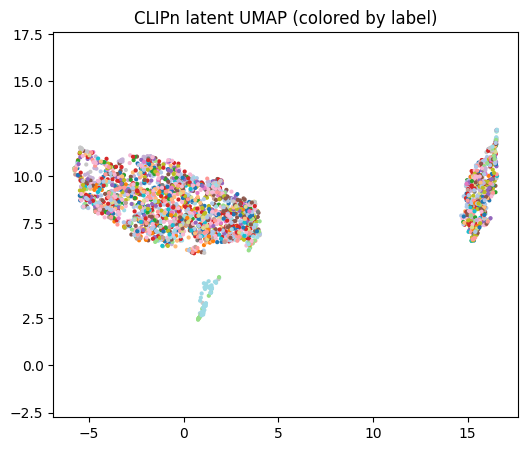

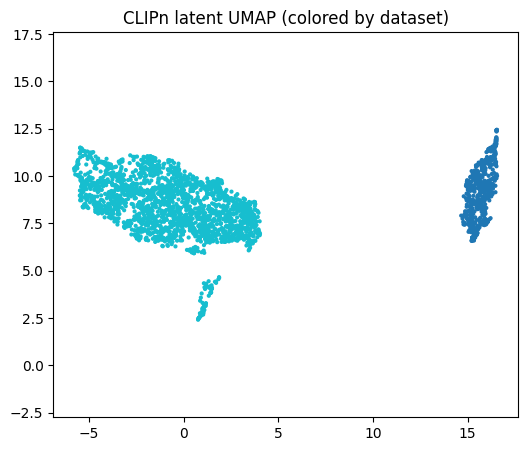

In [33]:
import umap
Z = clipn.predict(X)
umap_scatter(Z, y)

Running CLIPn ...


100%|██████████| 500/500 [00:39<00:00, 12.67it/s]


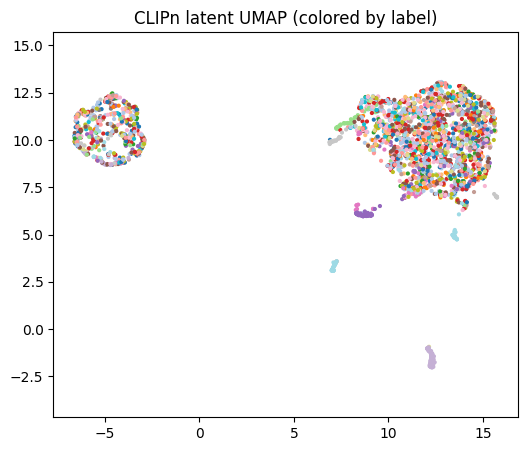

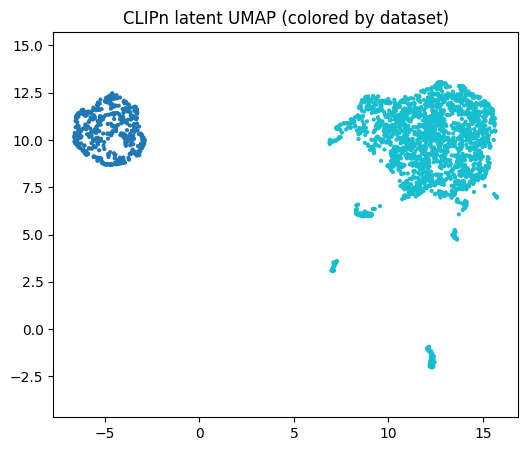

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 이미 만들어둔 X_cp, y_cp를 그대로 쓰면 됨:
Xc = X_ef[0]  # (523, 601)
Xl = X_ef[1]  # (2105, 119)
yc = y_ef[0]
yl = y_ef[1]

# dataset별 표준화 + PCA로 같은 차원 만들기
pca_dim = 50

Xc_std = StandardScaler().fit_transform(Xc)
Xl_std = StandardScaler().fit_transform(Xl)

Pc = PCA(n_components=pca_dim, random_state=0).fit_transform(Xc_std).astype(np.float32)
Pl = PCA(n_components=pca_dim, random_state=0).fit_transform(Xl_std).astype(np.float32)

X_pca = {0: Pc, 1: Pl}
y_pca = {0: yc, 1: yl}

clipn = CLIPn(X_pca, y_pca, latent_dim=10)
loss = clipn.fit(X_pca, y_pca, lr=1e-4, epochs=500)
Z = clipn.predict(X_pca)

umap_scatter(Z, y_pca)


In [34]:
print("CDRP EF:", cdrp["X_ef"].shape)
print("LINCS EF:", lincs["X_ef"].shape)
print("CDRP #ef_features:", len(cdrp["ef_features"]))
print("LINCS #ef_features:", len(lincs["ef_features"]))



CDRP EF: (1243, 1578)
LINCS EF: (3167, 1097)


KeyError: 'ef_features'

In [ ]:
import torch
print(torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("torch cuda:", torch.version.cuda)
print("device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)


1.10.0+cu102
cuda available: True
torch cuda: 10.2
device: NVIDIA GeForce RTX 3090
